# Testing of the Minimization Methods

Following methods will be tested
- Nelder Mead
- ....

Following testing functions will be used
- Rastrigin function
- Himmelblau function
- Eggholder function

In [19]:
import numpy as np
import matplotlib.pyplot as plt

import TestingFunctions as tf
import NelderMead as nm

func_optimal_points = {
    tf.RastriginFunction: np.array([[0, 0]]),
    tf.HimmelblauFunction: np.array([[3/5, 2/5], [-2.805118/5, 3.131312/5], [-3.779310/5, -3.283186/5], [3.584428/5, -1.848126/5]]),
    tf.EggholderFunction: np.array([[1, 404.2319/512]])
}

## A. Testing Functions Demonstrations
Simple plot to show the testing function shape.

In [2]:
xaxis = np.linspace(-1, 1, 1000)
yaxis = np.linspace(-1, 1, 1000)
X, Y = np.meshgrid(xaxis, yaxis)
rastringinZ = tf.RastriginFunction(X, Y)
himmelblauZ = tf.HimmelblauFunction(X, Y)
eggholderZ = tf.EggholderFunction(X, Y)

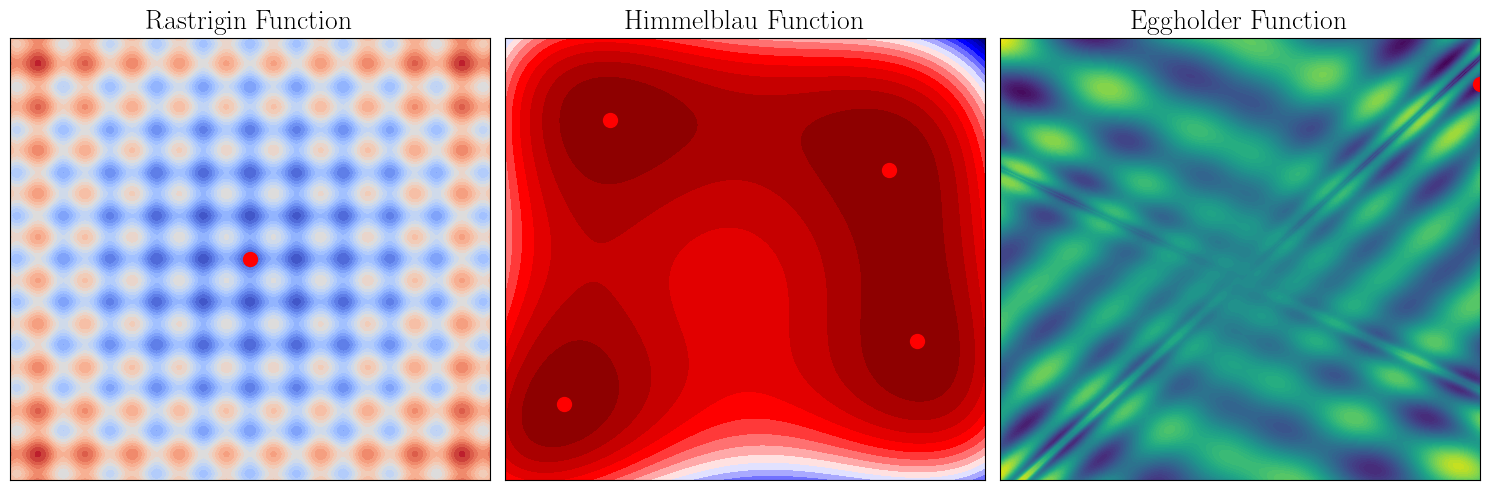

In [10]:
# plot into subplots in one figure with their minimum points marked with a red dot
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].contourf(X, Y, rastringinZ, levels=20, cmap='coolwarm')
axs[0].plot(0, 0, 'ro', markersize=10)
axs[0].set_title('Rastrigin Function', fontsize=20)
axs[0].set_xticks([])
axs[0].set_yticks([])
axs[1].contourf(X, Y, -himmelblauZ, levels=20, cmap='seismic')
axs[1].plot(3/5, 2/5, 'ro', markersize=10)
axs[1].plot(-2.805118/5, 3.131312/5, 'ro', markersize=10)
axs[1].plot(-3.779310/5, -3.283186/5, 'ro', markersize=10)
axs[1].plot(3.584428/5, -1.848126/5, 'ro', markersize=10)
axs[1].set_title('Himmelblau Function', fontsize=20)
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[2].contourf(X, Y, eggholderZ, levels=50, cmap='viridis')
axs[2].plot(1, 404.2319/512, 'ro', markersize=10)
axs[2].set_title('Eggholder Function', fontsize=20)
axs[2].set_xticks([])
axs[2].set_yticks([])
plt.tight_layout()
plt.show()

## B. Nelder Mead Testing
See Nelder Mead implementation in `NelderMead.py`.

In [14]:
rng = np.random.default_rng()
def NM_test_plot_history(func):
    initial_simplex = rng.uniform(-1, 1, size=(3, 2))
    myNM = nm.NelderMead(initial_simplex, func)
    history = myNM.auto_optimize(100, return_history=True)
    print("Optimal point:", myNM.Xs[0])
    print("Optimal value:", myNM.Zs[0])
    # plot the history of the optimization
    plt.figure(figsize=(6, 5))
    plt.contourf(X, Y, func(X, Y), levels=20, cmap='viridis')
    # plot initial simplex
    stacked_initial_simplex = np.vstack((initial_simplex, initial_simplex[0]))
    plt.plot(stacked_initial_simplex[:, 0], stacked_initial_simplex[:, 1], 'r-', markersize=8)
    for step in history:
        # add the first node again to the simplex
        simplex = np.vstack((step, step[0]))
        plt.plot(simplex[:, 0], simplex[:, 1], 'k-', alpha=0.5)
    plt.title('Nelder-Mead Optimization', fontsize=20)
    plt.xlabel('x', fontsize=14)
    plt.ylabel('y', fontsize=14)
    plt.show()

### B.1 Rastrigin Function

Optimal point: [0.58296686 0.38865499]
Optimal value: 12.934433277093026


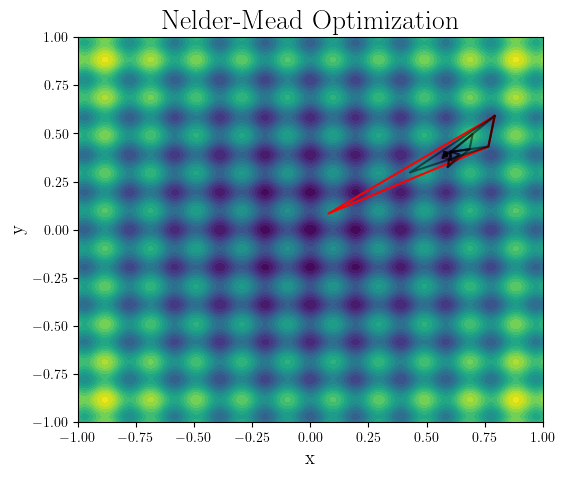

In [15]:
NM_test_plot_history(tf.RastriginFunction)

### B.2 Himmelblau Function

Optimal point: [-0.56104376  0.62629157]
Optimal value: 1.1599896943650356e-06


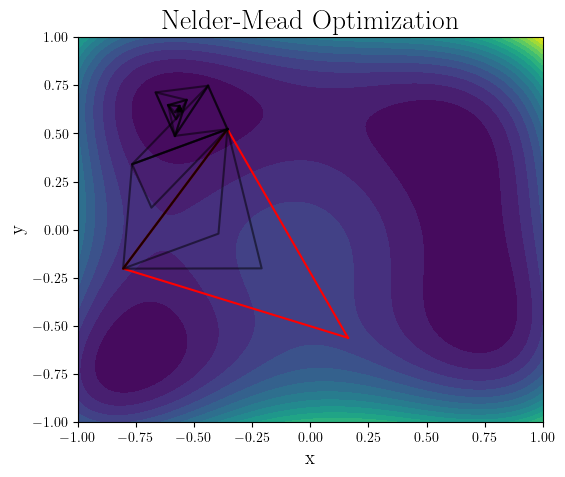

In [16]:
NM_test_plot_history(tf.HimmelblauFunction)

### B.3 Eggholder Function

Optimal point: [-0.90956535  0.75335272]
Optimal value: -894.5788988754382


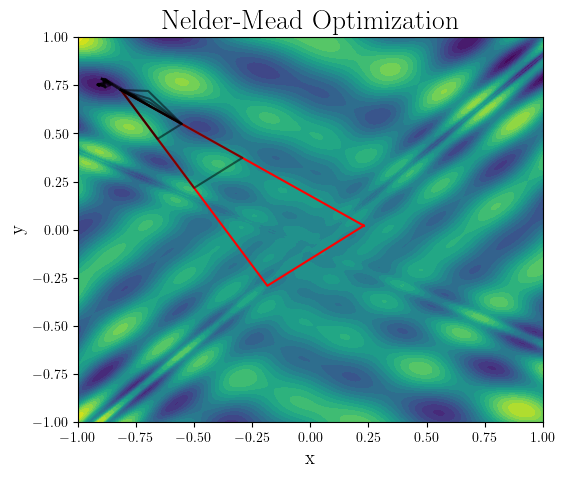

In [18]:
NM_test_plot_history(tf.EggholderFunction)

## E. Assesing Method Performance

### E.1 Nelder-Mead

In [20]:
# calculate 1000 random initial simplices and plot the distribution of results
# the criterion should be the distance from closest optimal point.

def test_NM(iterations, func, func_optimal_points):
    distances = []
    for _ in range(iterations):
        initial_simplex = rng.uniform(-1, 1, size=(3, 2))
        myNM = nm.NelderMead(initial_simplex, func)
        myNM.auto_optimize(100)
        optimal_point = myNM.Xs[0]
        closest_optimal_point = func_optimal_points[np.argmin(np.linalg.norm(func_optimal_points - optimal_point, axis=1))]
        distance = np.linalg.norm(optimal_point - closest_optimal_point)
        distances.append(distance)
    return distances

In [ ]:
RastriginNMTest = test_NM(1000, tf.RastriginFunction, np.atleast_2d(func_optimal_points[tf.RastriginFunction]))
HimmelblauNMTest = test_NM(1000, tf.HimmelblauFunction, np.atleast_2d(func_optimal_points[tf.HimmelblauFunction]))
EggholderNMTest = test_NM(1000, tf.EggholderFunction, np.atleast_2d(func_optimal_points[tf.EggholderFunction]))

AxisError: axis 1 is out of bounds for array of dimension 1

In [ ]:
# plot 